In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
products = pd.read_csv("products.csv")
inventory = pd.read_csv("inventory.csv")
orders = pd.read_csv("orders.csv")
suppliers = pd.read_csv("suppliers.csv")
sales = pd.read_csv("sales.csv")

In [3]:
products.head()

,Product_ID,Product_Name,Category,Cost,Price
0,1,Product_1,Accessories,277.36,363.03
1,2,Product_2,Components,421.91,653.89
2,3,Product_3,Tools,194.02,281.88
3,4,Product_4,Components,452.99,786.21
4,5,Product_5,Components,225.14,380.59


In [4]:
inventory.head()

,Product_ID,Warehouse,Stock_Level,Reorder_Level
0,1,Delhi,621,177
1,2,Hyderabad,257,91
2,3,Chennai,141,199
3,4,Bangalore,270,141
4,5,Bangalore,325,92


In [5]:
orders.head()

,Order_ID,Product_ID,Order_Date,Quantity,Delivery_Date
0,1,363,2023-09-04,115,2023-09-06
1,2,19,2023-09-16,153,2023-09-25
2,3,76,2024-02-19,123,2024-02-29
3,4,253,2023-09-10,126,2023-09-24
4,5,437,2023-12-12,130,2023-12-19


In [6]:
suppliers.head()

,Supplier_ID,Supplier_Name,Lead_Time,Location
0,1,Supplier_1,10,Germany
1,2,Supplier_2,12,China
2,3,Supplier_3,6,USA
3,4,Supplier_4,6,USA
4,5,Supplier_5,13,Japan


In [7]:
sales.head()

,Sale_ID,Product_ID,Sale_Date,Quantity,Revenue
0,1,422,2024-02-18,43,13121.88
1,2,387,2024-09-03,5,1573.10
2,3,478,2023-03-25,25,5829.75
3,4,321,2023-03-15,16,1866.24
4,5,378,2024-10-02,2,1015.10


In [8]:
products.shape

(500, 5)

In [9]:
inventory.shape

(500, 4)

In [10]:
orders.shape

(8000, 5)

In [11]:
suppliers.shape

(50, 4)

In [12]:
sales.shape

(10000, 5)

In [13]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    500 non-null    int64  
 1   Product_Name  500 non-null    object 
 2   Category      500 non-null    object 
 3   Cost          500 non-null    float64
 4   Price         500 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 19.7+ KB


In [14]:
inventory.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product_ID     500 non-null    int64 
 1   Warehouse      500 non-null    object
 2   Stock_Level    500 non-null    int64 
 3   Reorder_Level  500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       8000 non-null   int64 
 1   Product_ID     8000 non-null   int64 
 2   Order_Date     8000 non-null   object
 3   Quantity       8000 non-null   int64 
 4   Delivery_Date  8000 non-null   object
dtypes: int64(3), object(2)
memory usage: 312.6+ KB


In [16]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sale_ID     10000 non-null  int64  
 1   Product_ID  10000 non-null  int64  
 2   Sale_Date   10000 non-null  object 
 3   Quantity    10000 non-null  int64  
 4   Revenue     10000 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 390.8+ KB


In [17]:
suppliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Supplier_ID    50 non-null     int64 
 1   Supplier_Name  50 non-null     object
 2   Lead_Time      50 non-null     int64 
 3   Location       50 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.7+ KB


In [18]:
products.isnull().sum()

Product_ID      0
Product_Name    0
Category        0
Cost            0
Price           0
dtype: int64

In [19]:
inventory.isnull().sum()

Product_ID       0
Warehouse        0
Stock_Level      0
Reorder_Level    0
dtype: int64

In [20]:
orders.isnull().sum()

Order_ID         0
Product_ID       0
Order_Date       0
Quantity         0
Delivery_Date    0
dtype: int64

In [21]:
sales.isnull().sum()

Sale_ID       0
Product_ID    0
Sale_Date     0
Quantity      0
Revenue       0
dtype: int64

In [22]:
suppliers.isnull().sum()

Supplier_ID      0
Supplier_Name    0
Lead_Time        0
Location         0
dtype: int64

In [23]:
products.duplicated().sum()

0

In [24]:
orders.duplicated().sum()

0

In [25]:
sales.duplicated().sum()

0

In [26]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

In [27]:
orders['Delivery_Date'] = pd.to_datetime(orders['Delivery_Date'])

In [28]:
sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])

In [29]:
products.describe()

,Product_ID,Cost,Price
count,500.000000,500.000000,500.00000
mean,250.500000,270.221020,406.23834
std,144.481833,132.223845,205.27081
min,1.000000,52.080000,67.48000
25%,125.750000,150.437500,230.16500
50%,250.500000,267.275000,384.92000
75%,375.250000,386.375000,568.45500
max,500.000000,499.870000,864.68000


In [30]:
inventory.describe()

,Product_ID,Stock_Level,Reorder_Level
count,500.000000,500.000000,500.000000
mean,250.500000,504.480000,127.608000
std,144.481833,295.362149,44.246829
min,1.000000,1.000000,50.000000
25%,125.750000,241.750000,88.750000
50%,250.500000,512.000000,127.000000
75%,375.250000,759.250000,167.000000
max,500.000000,1000.000000,200.000000


In [31]:
sales.describe()

,Sale_ID,Product_ID,Quantity,Revenue
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,251.238300,25.404800,10320.690582
std,2886.89568,142.479655,14.412471,8416.576267
min,1.00000,1.000000,1.000000,78.560000
25%,2500.75000,128.000000,13.000000,3687.187500
50%,5000.50000,255.000000,25.000000,7912.830000
75%,7500.25000,372.250000,38.000000,15015.000000
max,10000.00000,500.000000,50.000000,42678.000000


In [32]:
sales_data = pd.merge(sales, products, on="Product_ID")

In [33]:
inventory_data = pd.merge(inventory, products, on="Product_ID")

In [34]:
top_products = sales_data.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product_Name
Product_461    903
Product_434    892
Product_273    878
Product_192    868
Product_139    865
Product_104    858
Product_359    847
Product_133    804
Product_384    802
Product_159    799
Name: Quantity, dtype: int64


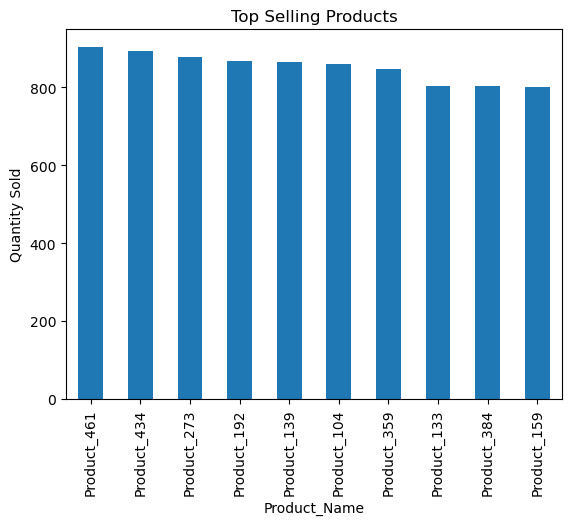

In [35]:
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

In [36]:
sales_data['Month'] = sales_data['Sale_Date'].dt.to_period('M')

monthly_sales = sales_data.groupby('Month')['Revenue'].sum()

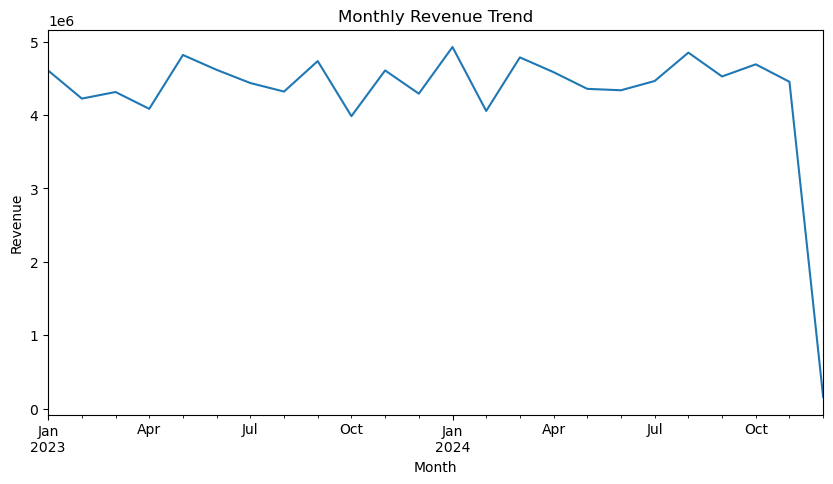

In [37]:
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

In [38]:
category_sales = sales_data.groupby("Category")["Revenue"].sum()

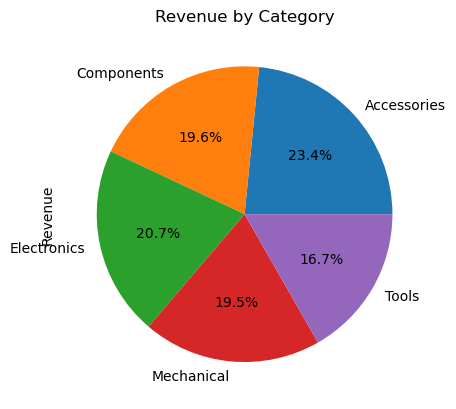

In [39]:
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Category")
plt.show()

In [40]:
low_stock = inventory[inventory["Stock_Level"] < inventory["Reorder_Level"]]

print(low_stock.head())

    Product_ID  Warehouse  Stock_Level  Reorder_Level
2            3    Chennai          141            199
15          16      Delhi           45            110
19          20  Hyderabad           31            178
20          21     Mumbai          130            172
22          23  Bangalore           44            168


In [41]:
low_stock.shape

(75, 4)

In [42]:
warehouse_stock = inventory.groupby("Warehouse")["Stock_Level"].sum()

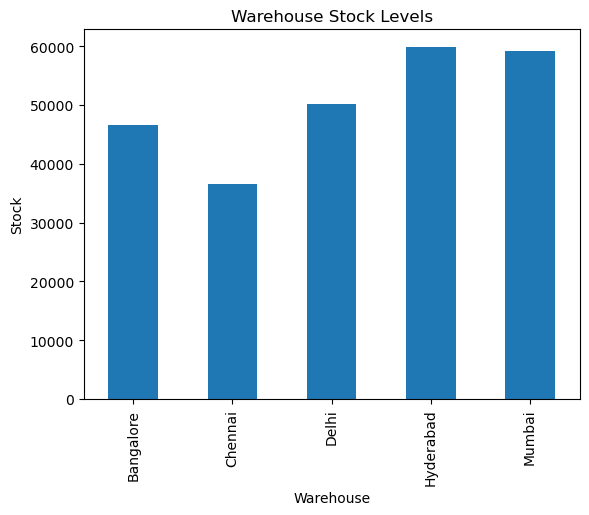

In [43]:
warehouse_stock.plot(kind='bar')
plt.title("Warehouse Stock Levels")
plt.ylabel("Stock")
plt.show()

In [44]:
orders['Delivery_Time'] = (orders['Delivery_Date'] - orders['Order_Date']).dt.days

In [45]:
orders['Delivery_Time'].mean()

8.5505

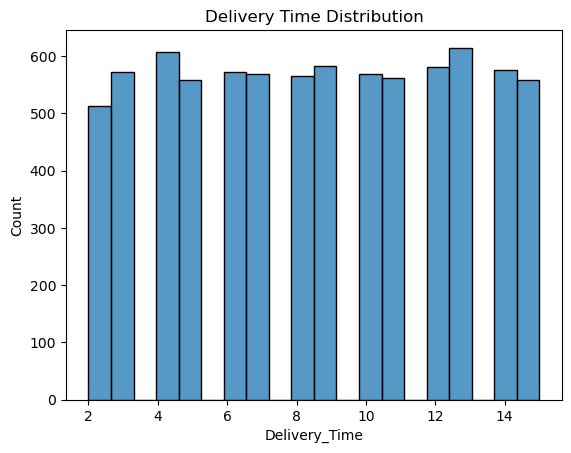

In [46]:
sns.histplot(orders['Delivery_Time'], bins=20)
plt.title("Delivery Time Distribution")
plt.show()

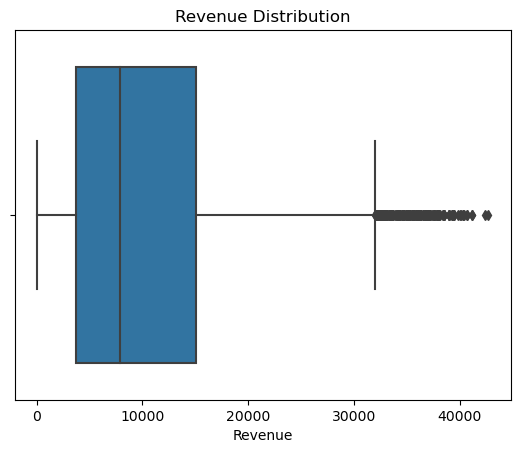

In [47]:
sns.boxplot(x=sales_data['Revenue'])
plt.title("Revenue Distribution")
plt.show()

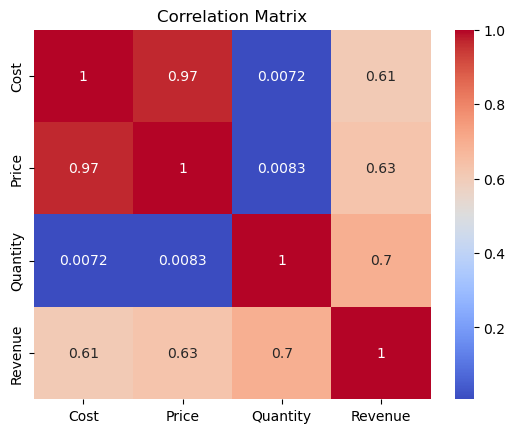

In [48]:
numeric_cols = sales_data[['Cost','Price','Quantity','Revenue']]

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [49]:
products.to_csv("clean_products.csv", index=False)
inventory.to_csv("clean_inventory.csv", index=False)
orders.to_csv("clean_orders.csv", index=False)
suppliers.to_csv("clean_suppliers.csv", index=False)
sales.to_csv("clean_sales.csv", index=False)